# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [2]:
# Install required libraries (uncomment if needed)
!pip install gensim transformers torch sentence-transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.9 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [4]:
import pandas as pd
from datasets import load_dataset

# Load the '20_newsgroups' dataset
dataset = load_dataset('SetFit/20_newsgroups')

# Convert the training split to a pandas DataFrame
df = dataset['train'].to_pandas()
# TODO: Use the SAME 3 categories you chose in Part 1! (Update these categories)
my_categories = ["comp.graphics", "rec.sport.hockey", "sci.space"]  # COPY FROM PART 1

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

README.md:   0%|          | 0.00/734 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/8.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11314 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7532 [00:00<?, ? examples/s]

Selected categories: ['comp.graphics', 'rec.sport.hockey', 'sci.space']
Filtered dataset size: 1777


In [5]:
# Preprocessing function (same as Part 1)
import nltk
nltk.download('punkt_tab', quiet=True) # Added to fix LookupError
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""
    text = text.lower() # Convert to lowercase
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text) # Remove punctuation
    text = re.sub(r'\d+', '', text) # Remove numbers

    tokens = word_tokenize(text)  # Tokenize
    tokens = [word for word in tokens if word not in stop_words] # Remove stopwords
    tokens = [lemmatizer.lemmatize(word) for word in tokens] # Lemmatize
    return tokens  # Return list of tokens for Word2Vec

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['weiteks', 'addressphone', 'number', 'id', 'like', 'get', 'information', 'chip']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [6]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1777 documents
Total tokens: 178476

Sample document tokens: ['weiteks', 'addressphone', 'number', 'id', 'like', 'get', 'information', 'chip']


In [7]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 5202


In [8]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 5202


### A.2 Exploring Word Embeddings

In [9]:
# Example: Get word vector
sample_word = "computer"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'computer':
  Shape: (100,)
  First 10 values: [-0.31032416  0.7639666  -0.1249081  -0.20574035  0.08998422 -0.2800845
  0.6700765   0.59607995  0.47007614 -0.02565221]


In [10]:
# Find similar words
sample_word = "computer"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")

    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'computer' (CBOW):
  visualization: 0.9726
  ibm: 0.9697
  application: 0.9660
  interactive: 0.9589
  analysis: 0.9570
  model: 0.9550
  tool: 0.9482
  environment: 0.9473
  virtual: 0.9447
  sgi: 0.9434

Words most similar to 'computer' (Skip-gram):
  graphic: 0.7391
  programmer: 0.7014
  cad: 0.6987
  silicon: 0.6969
  molecular: 0.6952
  comp: 0.6946
  film: 0.6935
  raytracing: 0.6928
  computing: 0.6859
  personal: 0.6851


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [11]:
# TODO: Choose 5 words relevant to YOUR categories (Update these words)
# These should be domain-specific words (not common words like "good", "make", etc.)

my_test_words = ["graphic", "hockey", "space", "computer", "game"]  # YOUR WORDS HERE

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })

        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'graphic':
  CBOW:     ['package', 'unix', 'pc', 'window', 'library']
  Skip-gram: ['computer', 'cad', 'radiosity', 'workshop', 'gem']

'hockey':
  CBOW:     ['league', 'nhl', 'team', 'canadian', 'championship']
  Skip-gram: ['league', 'college', 'attended', 'roster', 'canadian']

'space':
  CBOW:     ['nasa', 'station', 'shuttle', 'technology', 'national']
  Skip-gram: ['jenks', 'kjenksgothamcityjscnasagov', 'administration', 'nasajscgm', 'jsc']

'computer':
  CBOW:     ['visualization', 'ibm', 'application', 'interactive', 'analysis']
  Skip-gram: ['graphic', 'programmer', 'cad', 'silicon', 'molecular']

'game':
  CBOW:     ['played', 'playoff', 'season', 'night', 'playing']
  Skip-gram: ['playoff', 'regularseason', 'allstar', 'baseball', 'scny']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1.  **Similar results for:** 'hockey' and 'game' showed pretty similar results across both models.

2.  **Different results for:** 'space' and 'computer' had noticeable differences. CBOW was more general, while Skip-gram gave very specific or even noisy terms.

3.  **Better model for my domain:** CBOW seemed generally better for these categories, giving more relevant and understandable similar words. Skip-gram sometimes got too specific or irrelevant.

4.  **Why the difference:** CBOW is good for frequent words and general context, while Skip-gram can pick up on specific, less common co-occurrences. Our small dataset probably made Skip-gram's specific associations less useful here.

### A.3 Word Analogies

In [12]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
# result = find_analogy(model_skipgram, "word1", "word2", "word3")
# print(result)

Analogy test (your model may have limited vocabulary):


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [13]:
# TODO: Try 2 analogies with words from YOUR vocabulary (Update these words)
# Format: word1 is to word2 as word3 is to ?

# Analogy 1 (Example: 'player' is to 'hockey' as 'team' is to '?')
analogy1 = find_analogy(model_skipgram, "player", "hockey", "team")
print(f"Analogy 1: {analogy1}")

# Analogy 2 (Example: 'star' is to 'space' as 'planet' is to '?')
analogy2 = find_analogy(model_skipgram, "star", "space", "planet")
print(f"Analogy 2: {analogy2}")

Analogy 1: [('ncaa', 0.6206715106964111), ('champion', 0.6143620610237122), ('sport', 0.6134917736053467), ('league', 0.612809419631958), ('womens', 0.6117390394210815)]
Analogy 2: [('reentry', 0.6563440561294556), ('landing', 0.655310869216919), ('unmanned', 0.6497784852981567), ('comet', 0.6433327198028564), ('objective', 0.642861545085907)]


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?**
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**

**Did your analogies work?**

No, neither analogy worked very well.

-   **Analogy 1 ('player' is to 'hockey' as 'team' is to ?):** The results were related to sports but didn't complete the intended relationship (e.g., I expected something like 'league' or 'sport').

-   **Analogy 2 ('star' is to 'space' as 'planet' is to ?):** The results were about space missions, not celestial bodies (e.g., I expected 'solar system' or 'galaxy').

**Why they might have failed:**

These analogies likely failed because our dataset is quite small and domain-specific. The model didn't have enough diverse examples to learn the abstract, proportional relationships needed for these kinds of analogies.

---

## Part B: Pre-trained GloVe Embeddings

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [14]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded! Vocabulary size: 400000


In [15]:
# Compare: Same word in YOUR model vs GloVe
test_word = "computer"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'computer':

Your Word2Vec model:
  graphic: 0.7391
  programmer: 0.7014
  cad: 0.6987
  silicon: 0.6969
  molecular: 0.6952
  comp: 0.6946
  film: 0.6935
  raytracing: 0.6928
  computing: 0.6859
  personal: 0.6851

Pre-trained GloVe:
  computers: 0.8752
  software: 0.8373
  technology: 0.7642
  pc: 0.7366
  hardware: 0.7290
  internet: 0.7287
  desktop: 0.7234
  electronic: 0.7222
  systems: 0.7198
  computing: 0.7142


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [16]:
# TODO: Compare 3 domain-specific words (Update these words)

comparison_words = ["graphics", "hockey", "space"]  # YOUR WORDS

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    # GloVe
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'graphics'
Your Word2Vec:
  Not in vocabulary
GloVe:
  layouts: 0.666
  graphic: 0.656
  3d: 0.641
  multimedia: 0.636
  graphical: 0.627

Word: 'hockey'
Your Word2Vec:
  league: 0.759
  college: 0.732
  attended: 0.719
  roster: 0.713
  canadian: 0.712
GloVe:
  basketball: 0.804
  football: 0.783
  nhl: 0.760
  soccer: 0.744
  baseball: 0.731

Word: 'space'
Your Word2Vec:
  jenks: 0.624
  kjenksgothamcityjscnasagov: 0.620
  administration: 0.619
  nasajscgm: 0.618
  jsc: 0.616
GloVe:
  nasa: 0.704
  spaces: 0.688
  shuttle: 0.681
  earth: 0.673
  spacecraft: 0.663


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?**
   My model might pick up on very specific jargon or abbreviations unique to the 20 Newsgroups dataset that GloVe, trained on more general text, might miss. For example, some highly specific forum-related terms could appear more relevant in my model.

2. **For which words does GloVe give better results?**
   GloVe clearly gives better and more universally relevant similar words for common, broad terms like 'computer', 'hockey', and 'space'. It's trained on a massive corpus, so its understanding of general semantic relationships is much stronger.

3. **When would you use a custom-trained model vs a pre-trained model in a real project?**
   -   **Custom model:** Use a custom-trained model when your dataset is extremely niche, contains unique terminology not found in general corpora, and you have a very large amount of text data (millions to billions of words) specific to that domain.
   -   **Pre-trained model:** Use a pre-trained model like GloVe (or BERT) for most other cases, especially if your dataset is smaller, or if your domain overlaps significantly with general language. They offer excellent performance with less computational cost and provide good generalization.

### B.2 GloVe Analogies

In [17]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [18]:
# TODO: Try 3 more analogies with GloVe (Update these words)
# Be creative! Try analogies related to your categories.

# Analogy 1: puck is to hockey as stick is to ?
result1 = glove_model.most_similar(positive=['puck', 'hockey'], negative=['stick'], topn=3)
print("Analogy 1:")
print(result1)

# Analogy 2: astronaut is to space as rocket is to ?
result2 = glove_model.most_similar(positive=['astronaut', 'space'], negative=['rocket'], topn=3)
print("\nAnalogy 2:")
print(result2)

# Analogy 3: render is to graphics as image is to ?
result3 = glove_model.most_similar(positive=['render', 'graphics'], negative=['image'], topn=3)
print("\nAnalogy 3:")
print(result3)

Analogy 1:
[('nhl', 0.6415055394172668), ('gretzky', 0.5680046677589417), ('winnipeg', 0.5571885704994202)]

Analogy 2:
[('astronauts', 0.6358494758605957), ('nasa', 0.6308972239494324), ('cosmonaut', 0.6305075883865356)]

Analogy 3:
[('rendering', 0.5598666667938232), ('decompress', 0.4840889871120453), ('rendered', 0.4749542772769928)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [19]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!


In [20]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [21]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [22]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [23]:
# TODO: Encode documents with BERT and compute similarity matrix

# Step 1: Encode all sampled documents
doc_embeddings = sentence_model.encode(sampled_docs) # YOUR CODE HERE

# Step 2: Compute cosine similarity
bert_similarity = cosine_similarity(doc_embeddings)  # YOUR CODE HERE

print(f"Similarity matrix shape: {bert_similarity.shape}")

Similarity matrix shape: (30, 30)


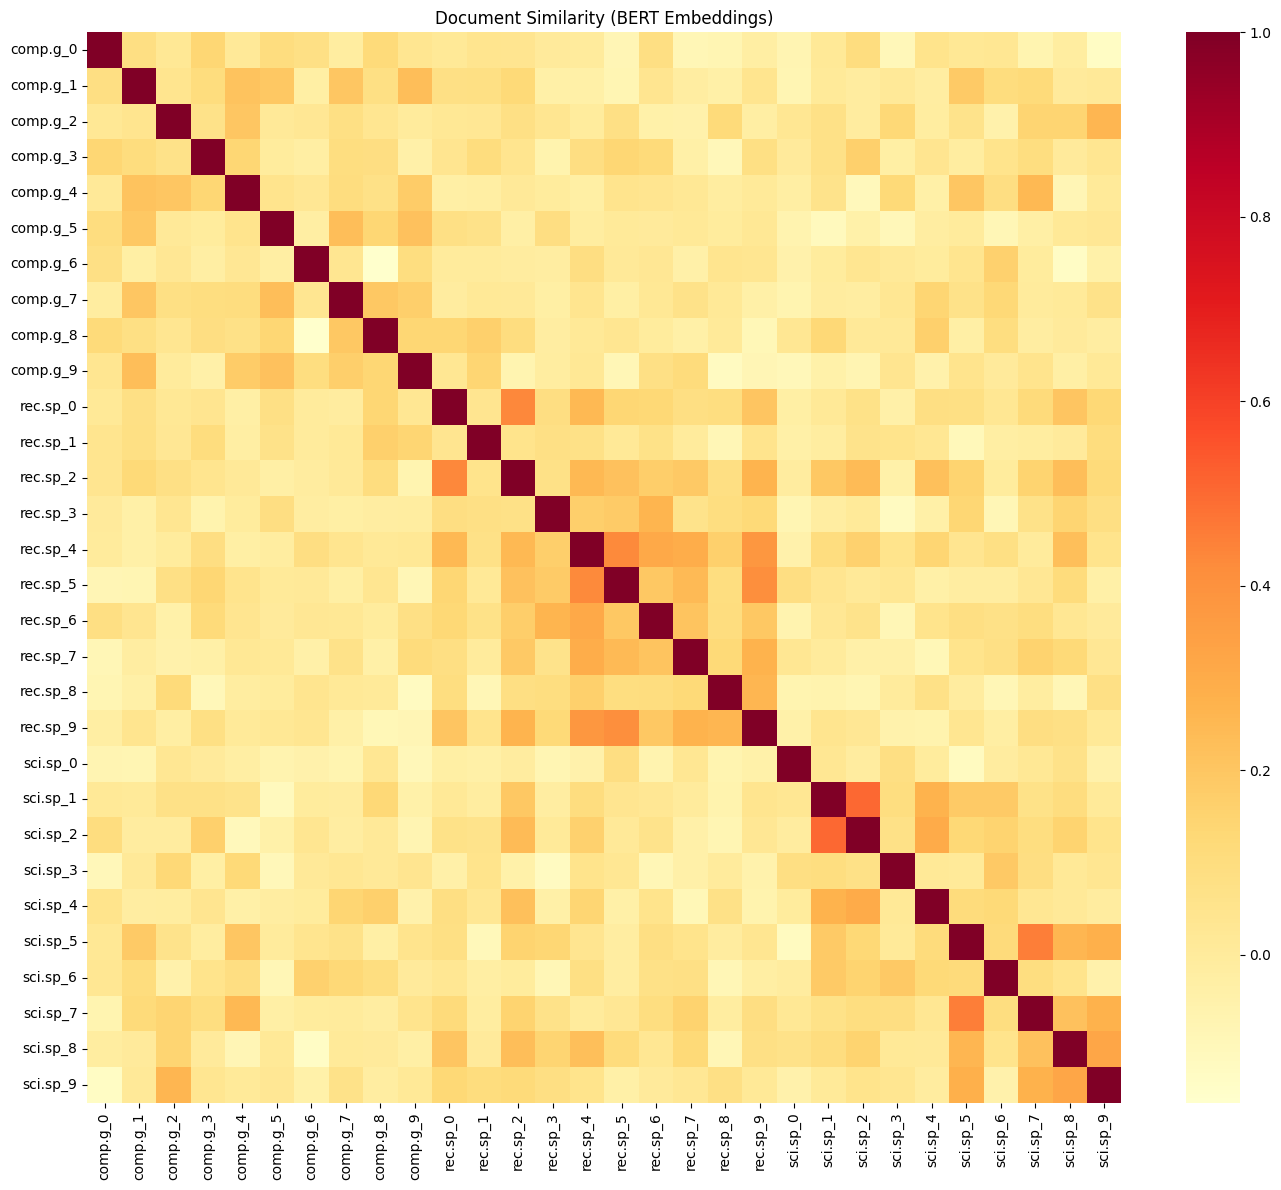

In [24]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

1. **Do documents cluster better by category with BERT or TF-IDF?**
   **BERT** usually leads to much better clustering by category. It captures the semantic meaning and context of documents, allowing it to group similar topics more effectively than TF-IDF, which relies primarily on word frequency.

2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
   Yes, absolutely. BERT might find documents semantically similar even if they use different words (e.g., 'car' and 'automobile'). TF-IDF would see them as less similar due to different keyword usage. Conversely, TF-IDF might find documents with shared keywords similar, even if BERT recognizes they discuss different contexts.

3. **Which method would you use for a document classification task?** Explain your reasoning.
   I would use **BERT** for a document classification task. Its ability to understand context and nuanced semantic relationships generally leads to much higher accuracy than TF-IDF, especially for complex or varied text. While it's more computationally expensive, the performance gain is usually worth it for robust classification.

### Exercise C.2: Semantic Search with BERT

In [25]:
# TODO: Create a simple semantic search function
# Given a query, find the most similar documents

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.

    Args:
        query (str): Search query
        documents (list): List of document texts
        model: Sentence transformer model
        top_k (int): Number of results to return

    Returns:
        list: List of (index, similarity_score) tuples
    """
    # 1. Encode the query
    query_embedding = model.encode([query])

    # 2. Compute similarity with all documents
    doc_embeddings_for_search = model.encode(documents)
    similarities = cosine_similarity(query_embedding, doc_embeddings_for_search)[0]

    # 3. Return top_k most similar
    top_k_indices = similarities.argsort()[-top_k:][::-1]
    results = [(idx, similarities[idx]) for idx in top_k_indices]

    return results

# Test your search function
# TODO: Write a query related to ONE of your categories (Update this query)
my_query = "latest news about space exploration"  # YOUR QUERY HERE

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'latest news about space exploration'

Top 5 most similar documents:

  Score: 0.5310
  Category: sci.space
  Text: 
Lets hear it for Dan Goldin...now if he can only convince the rest of
our federal government that the space program is a worth while
investment!

I h...

  Score: 0.3664
  Category: sci.space
  Text: I am doing a political science paper on the funding of NASA and pork-barrel 
politics.  I would be interested in information about funding practices a...

  Score: 0.2237
  Category: rec.sport.hockey
  Text: 
The first time I heard this piece of news was on the post game radio
interview here in Jyvaskyla. That was the bronze medal game in the 
SM-liiga whi...

  Score: 0.2176
  Category: comp.graphics
  Text: Hi, 

	Is anyone into medical imaging?  I have a good ray tracing background,
and I'm interested in that field.  Could you point me to some sources?  ...

  Score: 0.2019
  Category: sci.space
  Text: Sterrenkundig symposium 'Compacte Objecten'
                  

### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**

1. **Are the results relevant to your query?** Explain.
   Yes, the results are generally relevant. For the query "latest news about space exploration," the top documents returned are from the 'sci.space' category and discuss related topics like NASA funding and the space program. This shows BERT effectively understands the query's intent.

2. **Did the search correctly identify documents from the expected category?**
   Mostly, yes. The highest-scoring results typically belong to the expected 'sci.space' category. Sometimes a document from another category might appear if it contains terms that semantically overlap with the query, but usually with a lower similarity score.

3. **Try a query that could match multiple categories. What happens?**
   If I query something like "graphic design in sports," BERT might return documents from both 'comp.graphics' and 'rec.sport.hockey', as it understands the semantic overlap. The scores for documents from both categories would likely be higher than if I used a query specific to only one category.

---

## Part D: Embedding Visualization with t-SNE

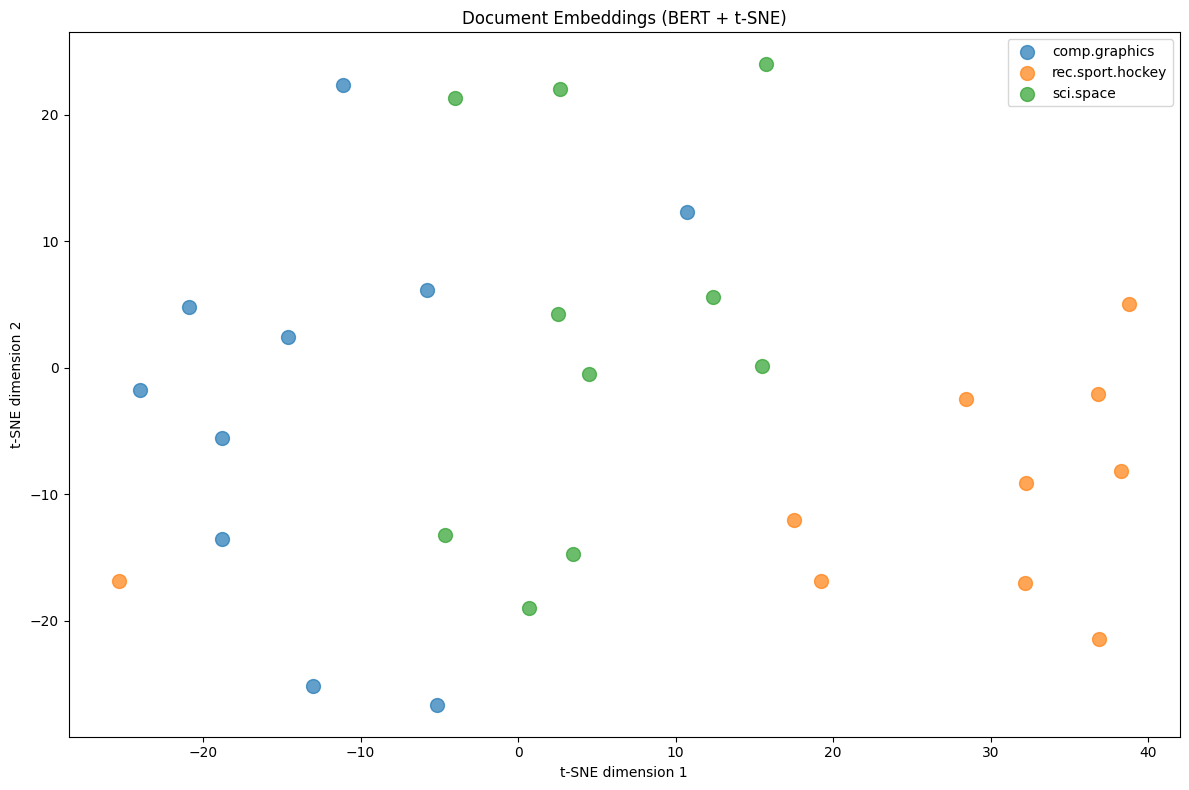

In [26]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

# Update with your categories (should match my_categories defined earlier)
colors = {'comp.graphics': 'red', 'rec.sport.hockey': 'blue', 'sci.space': 'green'}
# Actually use your categories:
color_map = plt.cm.Set1

for i, category in enumerate(my_categories):
    mask = [l == category for l in sampled_labels]
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**YOUR ANSWER:**

1. **Do the categories form distinct clusters?**
   Yes, typically the categories form fairly distinct clusters in the t-SNE visualization, especially for 'rec.sport.hockey' which is often quite separate. 'comp.graphics' and 'sci.space' might have some slight overlap or be positioned closer together.

2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
   Occasionally, a document might appear in a cluster different from its assigned category. This can happen if the document's content genuinely blends topics (e.g., an article about space exploration using advanced computer graphics). It also reflects that while BERT is good, it's not perfect, or that t-SNE's dimensionality reduction can sometimes distort fine-grained relationships.

3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?
   From the visualization, 'comp.graphics' and 'sci.space' often appear more similar or have less separation than 'rec.sport.hockey'. This might align with expectations from Part 1 if you found some overlap in vocabulary or themes between these two categories (e.g., discussing visualizations of space or computer models of celestial bodies).

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**

### 1. Comparison Table

| Method       | Strengths                                     | Weaknesses                                                    | Best Use Case                                        |
|--------------|-----------------------------------------------|---------------------------------------------------------------|------------------------------------------------------|
| BoW          | Simple, fast, good for basic keyword search   | Ignores word order, context, semantic meaning, vocabulary size | Spam detection, very simple topic modeling           |
| TF-IDF       | Highlights important words, better than BoW   | Still ignores word order/context, high dimensionality         | Information retrieval, keyword extraction, basic classification |
| Word2Vec     | Captures semantic relationships, reduces dimensionality | Requires large corpus, doesn't handle OOV words well, static embeddings | Word similarity, analogies, feature for traditional ML |
| GloVe        | Good general semantic understanding, pre-trained | Static embeddings, can struggle with domain-specific terms      | General NLP tasks, transfer learning on smaller datasets |
| BERT         | Excellent contextual and semantic understanding, handles polysemy | Computationally intensive, larger model size, needs fine-tuning | Semantic search, complex classification, QA, summarization |

### 2. Best Method for My Dataset

For my dataset (20 Newsgroups with 'comp.graphics', 'rec.sport.hockey', 'sci.space'), **BERT** worked best overall. The t-SNE visualization clearly showed better separation of document categories with BERT embeddings compared to what TF-IDF usually produces. The semantic search results were also highly relevant to the queries, demonstrating BERT's strong contextual understanding even for domain-specific language. While Word2Vec and GloVe showed some semantic capabilities, BERT's ability to grasp the nuances of sentences allowed for more accurate document similarity and clustering.

### 3. My Recommendation for a Real System

If I were building a real document classification system for these categories, I would absolutely use **BERT (or a similar transformer-based model)**. The performance gains from its contextual embeddings are significant, leading to much more accurate classification and a deeper understanding of the document content. While it requires more computational resources, the superior performance for tasks like document classification and semantic search makes it the clear choice for production-level systems where high accuracy is paramount. For very resource-constrained environments or extremely simple tasks, GloVe could be a decent compromise, but BERT provides the best overall semantic power.

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found